# When affected siblings share more DNA

Two full siblings can share zero, one, or two chromosome copies identical by descent (IBD) at a locus. If both have a disease, do they share more copies near a disease locus than Mendelian transmission predicts?

## Start from Mendel

Each parent passes one of two copies to each child. For two siblings, the paternal and maternal sharing events are independent, each with probability $1/2$. If $K$ is their number of shared copies,

$$K=B_{\mathrm{father}}+B_{\mathrm{mother}},\qquad B_{\mathrm{father}},B_{\mathrm{mother}}\sim\operatorname{Bernoulli}(1/2).$$

Thus $P(K=0,1,2)=(1/4,1/2,1/4)$ and $E(K)=1$. Under no linkage between the marker and disease, this is also the expectation for affected sibling pairs.


## A small example

Suppose the number of shared copies is known for 20 affected sibling pairs at one marker. Two pairs share no copies, eight share one, and ten share two. Their mean is $28/20=1.4$, above the Mendelian expectation of $1$.

If the pairs are independent and sharing is known without error, the total number of shared parental copies under no linkage follows $\operatorname{Binomial}(40,1/2)$. We can compare the observed total of 28 with that distribution.


In [1]:
n_pairs <- 20L
observed_counts <- c(`0` = 2L, `1` = 8L, `2` = 10L)
stopifnot(sum(observed_counts) == n_pairs)

observed_total <- sum((0:2) * observed_counts)
observed_mean <- observed_total / n_pairs
null_tail <- pbinom(observed_total - 1L, size = 2L * n_pairs,
                    prob = 0.5, lower.tail = FALSE)
c(Mendelian_mean = 1, observed_mean = observed_mean,
  probability_of_28_or_more = null_tail)

Mendelian_mean             observed_mean probability_of_28_or_more 
              1.000000000               1.400000000               0.008294502

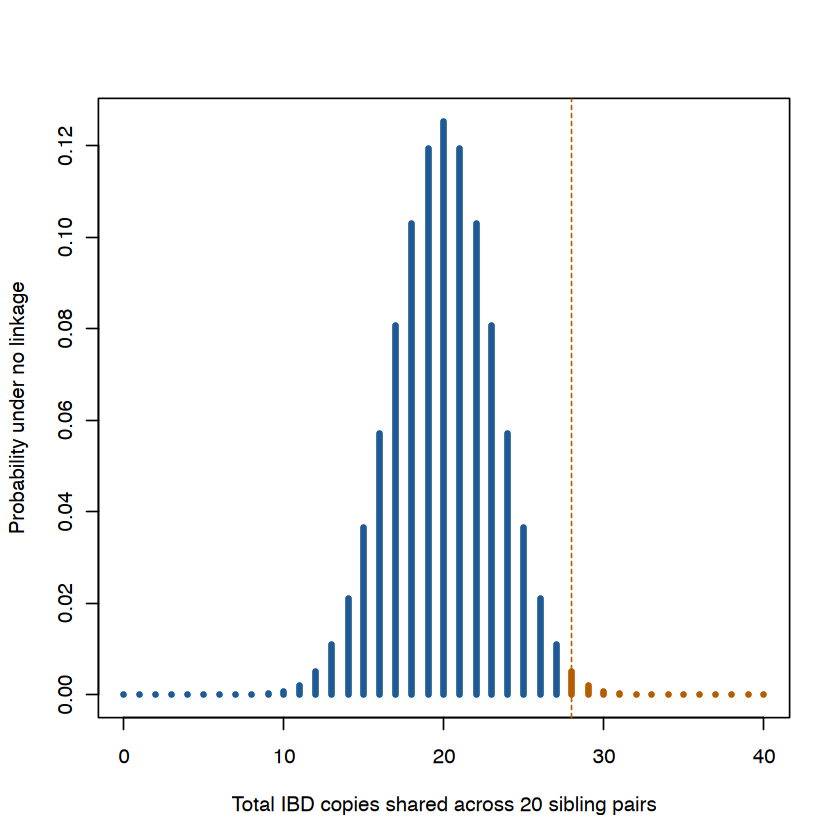

In [2]:
possible_total <- 0:(2L * n_pairs)
null_probability <- dbinom(possible_total, size = 2L * n_pairs, prob = 0.5)
plot(possible_total, null_probability, type = "h", lwd = 4,
     col = ifelse(possible_total >= observed_total, "#B55D00", "#1F5A94"),
     xlab = "Total IBD copies shared across 20 sibling pairs",
     ylab = "Probability under no linkage")
abline(v = observed_total, lty = 2, col = "#B55D00")

## Marker genotypes do not reveal IBD perfectly

The example treats $K$ as known. With real marker genotypes $G$, a full local IBD model gives $P(K_{im}=k\mid G_i)$ for sibling pair $i$ at marker $m$. We use each pair's expected sharing, $\sum_{k=0}^{2}kP(K_{im}=k\mid G_i)$, and average over affected pairs. A local excess points toward a disease region.

This is **nonparametric linkage**. Its baseline comes from Mendelian transmission. It does not require a disease-allele frequency or penetrance model. The small calculation above tests one marker with independent pairs and known IBD; a genome scan with uncertain IBD needs a calibrated analysis across markers.

## What to remember

- **Concept.** Affected siblings can share more DNA near a disease locus than Mendel predicts for siblings.
- **Methodological insight.** Compare local IBD sharing among affected relatives with its Mendelian expectation.
- **Connection.** Linked markers help infer the local IBD state; the disease question concerns whether affected pairs share more than expected.

## Further detail

- [Kruglyak et al. (1996), *Parametric and nonparametric linkage analysis*](https://pubmed.ncbi.nlm.nih.gov/8651312/).
- [Kong and Cox (1997), *Allele-sharing models*](https://pubmed.ncbi.nlm.nih.gov/9345087/).
- The 20-pair counts are an original course example.
